In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load Processed Dataset

In [2]:
df = pd.read_csv("../data/processed/online_retail_final.csv")

Convert InvoiceDate

In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

Find Latest Purchase Date


In [4]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


Calculate RFM Table


In [5]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

Rename Columns

In [6]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

View Results

In [7]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


Check Statistics

In [8]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


Histograms

Recency

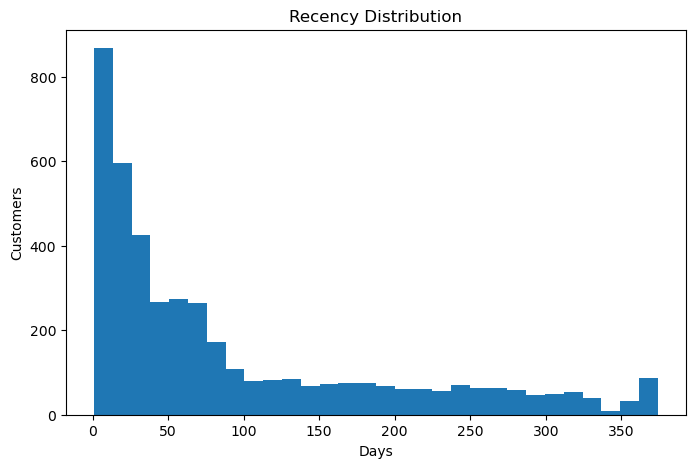

In [9]:
plt.figure(figsize=(8,5))
plt.hist(rfm["Recency"], bins=30)

plt.title("Recency Distribution")
plt.xlabel("Days")
plt.ylabel("Customers")

plt.show()

Frequency

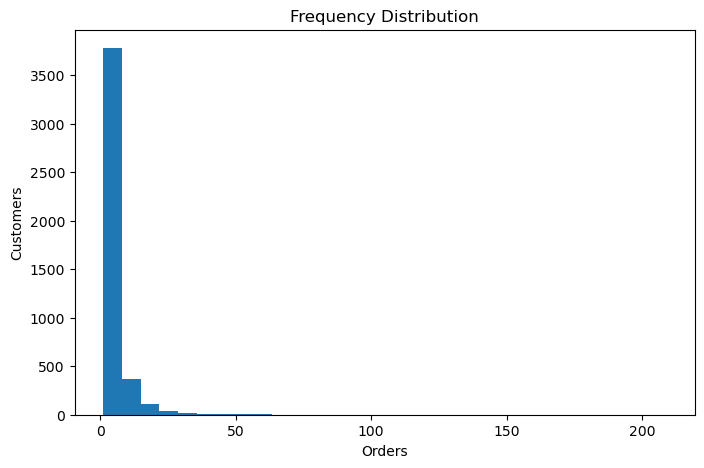

In [10]:
plt.figure(figsize=(8,5))
plt.hist(rfm["Frequency"], bins=30)

plt.title("Frequency Distribution")
plt.xlabel("Orders")
plt.ylabel("Customers")

plt.show()

Monetary

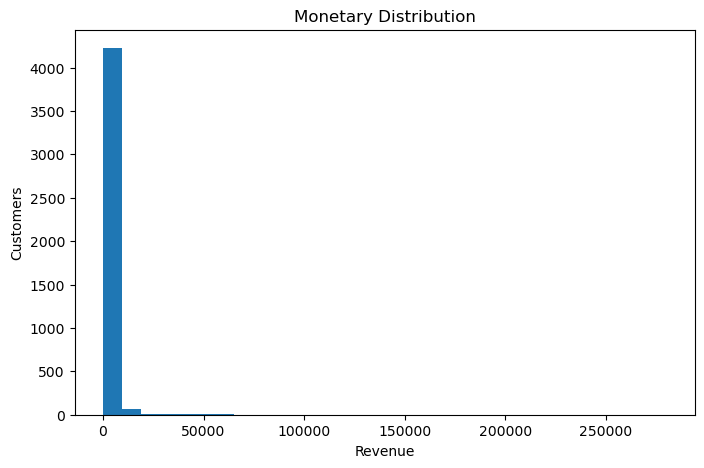

In [11]:
plt.figure(figsize=(8,5))
plt.hist(rfm["Monetary"], bins=30)

plt.title("Monetary Distribution")
plt.xlabel("Revenue")
plt.ylabel("Customers")

plt.show()

Top Customers by Revenue

In [12]:
rfm.sort_values(
    by="Monetary",
    ascending=False
).head(10)

,Recency,Frequency,Monetary
CustomerID,,,
14646,2,73,280206.02
18102,1,60,259657.30
17450,8,46,194390.79
16446,1,2,168472.50
14911,1,201,143711.17
12415,24,21,124914.53
14156,10,55,117210.08
17511,3,31,91062.38
16029,39,63,80850.84


Save RFM Dataset

In [13]:
rfm.to_csv("../data/processed/rfm_data.csv")

# Business Insights

1. Customers with lower Recency values are more active.
2. A small number of customers contribute a large portion of total revenue.
3. High-frequency customers are valuable for retention campaigns.
4. Monetary values indicate potential VIP customers.
5. RFM metrics will be used in Week 2 for customer segmentation.